# 🌿 VedaVision — Module 3
# Notebook 02H — Preprocessing Pipeline for Health Assessment
### Same segmentation core as species-ID preprocessing, WITHOUT the steps that would erase disease symptoms

---
**Input**  : `dataset/health_raw/species/healthy/top|bottom/*.jpg`
             and `dataset/health_raw/species/damaged/{low,medium,high}/top|bottom/*.jpg`

**Output** : same nested structure under `dataset/health_preprocessed/...`

---
### ⚠️ Why this is a SEPARATE notebook from species-ID preprocessing

Two steps in the species-ID pipeline were specifically built to correct or
remove dark/desaturated patches on the leaf surface -- treating them as
shadow or as a background-connected crevice. For species identification
that's correct: a shadow or a leaflet gap isn't part of the species'
identity, so smoothing/removing it is safe.

For health assessment, that assumption breaks: **a disease lesion,
necrotic spot, or fungal patch is ALSO a dark, desaturated, non-green
region on the leaf** -- there is no colour/brightness rule that can tell
"this is shadow" apart from "this is disease" from pixel values alone.
Running the species-ID shadow-correction logic on health data risks
editing away the exact symptoms the model is supposed to learn to detect.

**Removed here:**
- `correct_leaf_shadow()` -- illumination correction on the leaf surface.
  Not applied at all. Any real shadow-on-leaf artifact is left as-is,
  imperfect but honest, rather than risking erasing a real symptom.
- Per-image colour normalization -- was never in the species-ID pipeline
  either (removed earlier for washing out species colour signal), and
  would be even more damaging here, since disease severity is partly
  DEFINED by colour shift (green -> yellow -> brown/black). Per-image
  stretching would normalize away the exact signal that indicates
  severity.

**Kept, but with more conservative defaults:**
- The "dark enclosed blob = shadow crevice" check in `segment_leaf()`
  is kept (some leaf species genuinely have background-coloured gaps
  between leaflets, independent of health status), but `min_shadow_area`
  defaults MUCH higher here than in the species-ID pipeline, so it only
  strips large, unambiguous background-sized gaps -- not a lesion-sized
  dark patch on real leaf tissue. **Check Cell 7 specifically on your
  "high" severity images** -- that's the category most likely to reveal
  whether this threshold needs adjusting for your actual lesion sizes.
- `crop_to_leaf_bbox()` and CLAHE/light denoising are unchanged and still
  appropriate for health data.

---
### Pipeline:
```
Original Image
      |
  1.  Resize                    -> 512x512 working size
  2-8. Segment leaf (Saturation threshold + bridge-break fill-holes +
      component-level dark/bright check + small-blob cleanup +
      morphological close/open + keep largest contour(s))
  9.  Crop to leaf bounding box (removes camera-distance artifact)
  10. Apply mask, replace background with white
      -- NO shadow/illumination correction on the leaf surface
  11. CLAHE (LAB L channel, once)
  12. Light denoising (bilateral, edge-preserving) + edge trim
  13. Resize to 224x224
```
---
### Folder structure reminder
`species/healthy/{top,bottom}` and `species/damaged/{low,medium,high}/{top,bottom}` is the structure used here. Same
leakage rule as species-ID applies: when you later split into train/test,
split by SPECIMEN (a leaf's top and bottom stay together on the same
side), never by individual image.

---
### Run Order:
```
02H_Preprocessing_Health.ipynb (this notebook) -> 04H_Feature_Extraction_Health.ipynb
```
---


## Cell 1 — Install Libraries

In [4]:
!pip install opencv-python-headless scikit-image matplotlib numpy tqdm pandas -q
print('✅ Libraries installed!')

✅ Libraries installed!


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\User\\Documents\\Projects\\Veda_Vision\\ayurveda-recognition\\venv\\Lib\\site-packages\\cv2\\cv2.pyd'
Check the permissions.



## Cell 2 — Import Libraries

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import gc
from glob import glob
from tqdm import tqdm
#from google.colab import drive

def bgr2rgb(img):
    """OpenCV loads BGR; matplotlib expects RGB. Used only for display/plotting."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print('✅ All libraries imported! (bgr2rgb helper added)')

✅ All libraries imported! (bgr2rgb helper added)


## Cell 3 — Mount Google Drive & Configure Paths
**Only change things in this cell**

In [6]:
 

# ============================================================
# ✏️  UPDATE THESE PATHS
# ============================================================
RAW_HEALTH_PATH    = 'C:/Users/User/Documents/UOM/L4S2/Research/Health_New'
PREPROCESSED_PATH  = 'C:/Users/User/Documents/UOM/L4S2/Research/Health_New/health_preprocessed'
LOGS_PATH          = 'C:/Users/User/Documents/UOM/L4S2/Research'

SEVERITY_LEVELS = ['healthy', 'low', 'medium', 'high']   # logical labels used in code/reports
VIEWS           = ['top', 'bottom']

# Maps each logical severity label -> actual folder path *parts* on disk.
# 'healthy' sits directly under species/, damaged levels sit nested under species/damaged/.
STATUS_PATH_PARTS = {
    'healthy': ('healthy',),
    'low':     ('damaged', 'low'),
    'medium':  ('damaged', 'medium'),
    'high':    ('damaged', 'high'),
}
WORK_SIZE       = (512, 512)
# Bumped from 224x224 (species-ID default) to 384x384: classical features here
# (spot counts, GLCM/LBP texture, damaged-area ratio) are computed on THIS image,
# not fed to a CNN -- small early-stage lesions can shrink below a usable pixel
# footprint at 224x224. Check Cell 7 on 'low' severity samples; if a visible spot
# still looks barely-there at 384, raise this further (e.g. 512, matching WORK_SIZE).
TARGET_SIZE     = (384, 384)
# ============================================================

SPECIES_FOLDERS = [
    d for d in os.listdir(RAW_HEALTH_PATH) 
    if os.path.isdir(os.path.join(RAW_HEALTH_PATH, d))
]

os.makedirs(PREPROCESSED_PATH, exist_ok=True)
os.makedirs(LOGS_PATH,         exist_ok=True)

print(f'✅ Paths configured!')
print(f'📁 Input  : {RAW_HEALTH_PATH}')
print(f'📁 Output : {PREPROCESSED_PATH}')
print(f'🩺 Severity levels: {SEVERITY_LEVELS}')
print(f'📂 Views          : {VIEWS}')

✅ Paths configured!
📁 Input  : C:/Users/User/Documents/UOM/L4S2/Research/Health_New
📁 Output : C:/Users/User/Documents/UOM/L4S2/Research/Health_New/health_preprocessed
🩺 Severity levels: ['healthy', 'low', 'medium', 'high']
📂 Views          : ['top', 'bottom']


## Cell 4 — Helper Functions

In [7]:
def get_images(base_path, severity, view):
    """
    severity = one of SEVERITY_LEVELS ('healthy' / 'low' / 'medium' / 'high')
    Maps to the nested folder via STATUS_PATH_PARTS:
        healthy -> species/healthy/view
        low/medium/high -> species/damaged/<level>/view
    Searches across ALL species subfolders: base_path/*/<parts>/view/*.ext
    """
    parts = STATUS_PATH_PARTS[severity]
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        search_pattern = os.path.join(base_path, '*', *parts, view, ext)
        image_paths.extend(glob(search_pattern))
    return image_paths


## Cell 5 — Segmentation & Preprocessing Functions

Core segmentation is identical to the species-ID pipeline (same
bridge-break fill-holes, component-level dark/bright check, keep-largest-
contour logic -- all validated there). The differences are the removed
shadow-correction step and the more conservative `min_shadow_area` /
`dark_v_thresh` defaults, explained in the intro above.

In [8]:
def get_border_connected_background(candidate_bg, bridge_break_px=7):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_break_px, bridge_break_px))
    eroded_bg = cv2.erode(candidate_bg, kernel)

    h, w = eroded_bg.shape
    padded = cv2.copyMakeBorder(eroded_bg, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=255)
    flood_seed = np.zeros((h + 4, w + 4), np.uint8)
    filled = padded.copy()
    cv2.floodFill(filled, flood_seed, (0, 0), 128)
    border_bg = ((filled == 128).astype(np.uint8) * 255)[1:-1, 1:-1]

    border_bg = cv2.dilate(border_bg, kernel)
    border_bg = cv2.bitwise_and(border_bg, candidate_bg)
    return border_bg


def remove_small_blobs(mask, min_area=100):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == label] = 255
    return clean


def keep_largest_contours(mask, keep_ratio=0.05, min_absolute_area=2000):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask
    areas = [cv2.contourArea(c) for c in contours]
    largest_area = max(areas)
    clean = np.zeros_like(mask)
    for c, a in zip(contours, areas):
        if a >= largest_area * keep_ratio or a >= min_absolute_area:
            cv2.drawContours(clean, [c], -1, 255, thickness=cv2.FILLED)
    return clean


def segment_leaf(image, dark_v_thresh=90, min_shadow_area=1500,
                  max_artifact_area=150, bridge_break_px=7,
                  morph_kernel_size=3, min_blob_area=100,
                  otsu_relax_factor=0.6, keep_ratio=0.05,
                  min_absolute_area=2000):
    """
    Same segmentation logic as the species-ID pipeline.

    KEY DIFFERENCE: min_shadow_area defaults to 1500 here (vs 200 for
    species-ID). This is the single most important tuning knob for
    health data -- it's the size threshold above which a dark enclosed
    blob gets treated as background/shadow and removed. Set too low, a
    real lesion gets wiped out. Set too high, a real background gap
    between leaflets survives as leaf. There's no universal correct
    value -- it depends on how large your actual lesions are relative
    to any real leaflet gaps in your species. CHECK THIS on your "high"
    severity images in Cell 7 before running the full batch.
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    otsu_thresh, _ = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    relaxed_thresh = otsu_thresh * otsu_relax_factor
    _, candidate_leaf = cv2.threshold(s, relaxed_thresh, 255, cv2.THRESH_BINARY)
    candidate_bg = cv2.bitwise_not(candidate_leaf)

    border_bg = get_border_connected_background(candidate_bg, bridge_break_px)

    enclosed = cv2.bitwise_and(candidate_bg, cv2.bitwise_not(border_bg))
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(enclosed, connectivity=8)
    dark_enclosed = np.zeros_like(enclosed)
    undecided = []
    for label in range(1, num_labels):
        comp = (labels == label)
        if stats[label, cv2.CC_STAT_AREA] < min_shadow_area:
            undecided.append(label)
            continue
        if np.median(v[comp]) < dark_v_thresh:
            dark_enclosed[comp] = 255
        else:
            undecided.append(label)

    kernel_adj = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    dilated_dark = cv2.dilate(dark_enclosed, kernel_adj, iterations=1)
    for label in undecided:
        comp = (labels == label)
        if stats[label, cv2.CC_STAT_AREA] < max_artifact_area and np.any(dilated_dark[comp]):
            dark_enclosed[comp] = 255

    background_mask = cv2.bitwise_or(border_bg, dark_enclosed)
    leaf_mask = cv2.bitwise_not(background_mask)

    leaf_mask = remove_small_blobs(leaf_mask, min_area=min_blob_area)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    leaf_mask = keep_largest_contours(leaf_mask, keep_ratio=keep_ratio,
                                       min_absolute_area=min_absolute_area)

    return leaf_mask


def crop_to_leaf_bbox(image, mask, padding_frac=0.10):
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image, mask
    x, y, w, h = cv2.boundingRect(coords)
    pad_x, pad_y = int(w * padding_frac), int(h * padding_frac)
    x0, y0 = max(0, x - pad_x), max(0, y - pad_y)
    x1 = min(image.shape[1], x + w + pad_x)
    y1 = min(image.shape[0], y + h + pad_y)
    return image[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def remove_background(image, mask):
    result = image.copy()
    result[mask == 0] = [255, 255, 255]
    return result


def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def apply_light_denoise(image, mask, edge_trim_px=2, sigma_color=18, sigma_space=18):
    """
    sigma_color/sigma_space lowered from 50->18 (species-ID used 50 safely since
    species shape/color doesn't depend on fine texture). At 50 here, small necrotic
    speckling and fine disease texture -- exactly what GLCM/LBP severity features
    need later -- was getting smoothed away along with sensor noise. 18 removes
    sensor noise while preserving lesion-scale texture; re-check Cell 7 on 'low'
    severity if you tune this further.
    """
    result = cv2.bilateralFilter(image, d=9, sigmaColor=sigma_color, sigmaSpace=sigma_space)
    k = edge_trim_px * 2 + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    tight_mask = cv2.erode(mask, kernel)
    result[tight_mask == 0] = [255, 255, 255]
    return result

print('✅ Segmentation & preprocessing functions defined! (no shadow-correction step)')

✅ Segmentation & preprocessing functions defined! (no shadow-correction step)


## Cell 6 — Full Pipeline Function
Note: NO `correct_leaf_shadow()` call -- see intro for why

In [9]:
def preprocess_image(image_bgr):
    if image_bgr is None:
        return None

    img  = cv2.resize(image_bgr, WORK_SIZE)
    mask = segment_leaf(img)

    coverage = np.sum(mask > 0) / mask.size
    if coverage < 0.02 or coverage > 0.95:
        return None

    img, mask = crop_to_leaf_bbox(img, mask)
    # NOTE: no correct_leaf_shadow() here -- disease symptoms on the leaf
    # surface must be preserved exactly as photographed
    no_bg     = remove_background(img, mask)
    clahe_img = apply_clahe(no_bg)
    denoised  = apply_light_denoise(clahe_img, mask)

    final = cv2.resize(denoised, TARGET_SIZE)
    return final

print('✅ preprocess_image() ready')

✅ preprocess_image() ready


## Cell 7 — Test on ONE Image Per Severity Level & See Every Step

⚠️ Pay particular attention to the "high" severity output here — check
that visible lesions/necrotic patches survived in the final image rather
than being painted white. If they didn't, lower `min_shadow_area` in
`segment_leaf()` (Cell 5) and re-run this cell.

C:\Users\User\AppData\Local\Temp\ipykernel_23140\331741074.py:38: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_23140\331741074.py:39: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/02Hb_preprocessing_{severity}.png', bbox_inches='tight', dpi=120)
c:\Users\User\Documents\Projects\Veda_Vision\ayurveda-recognition\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


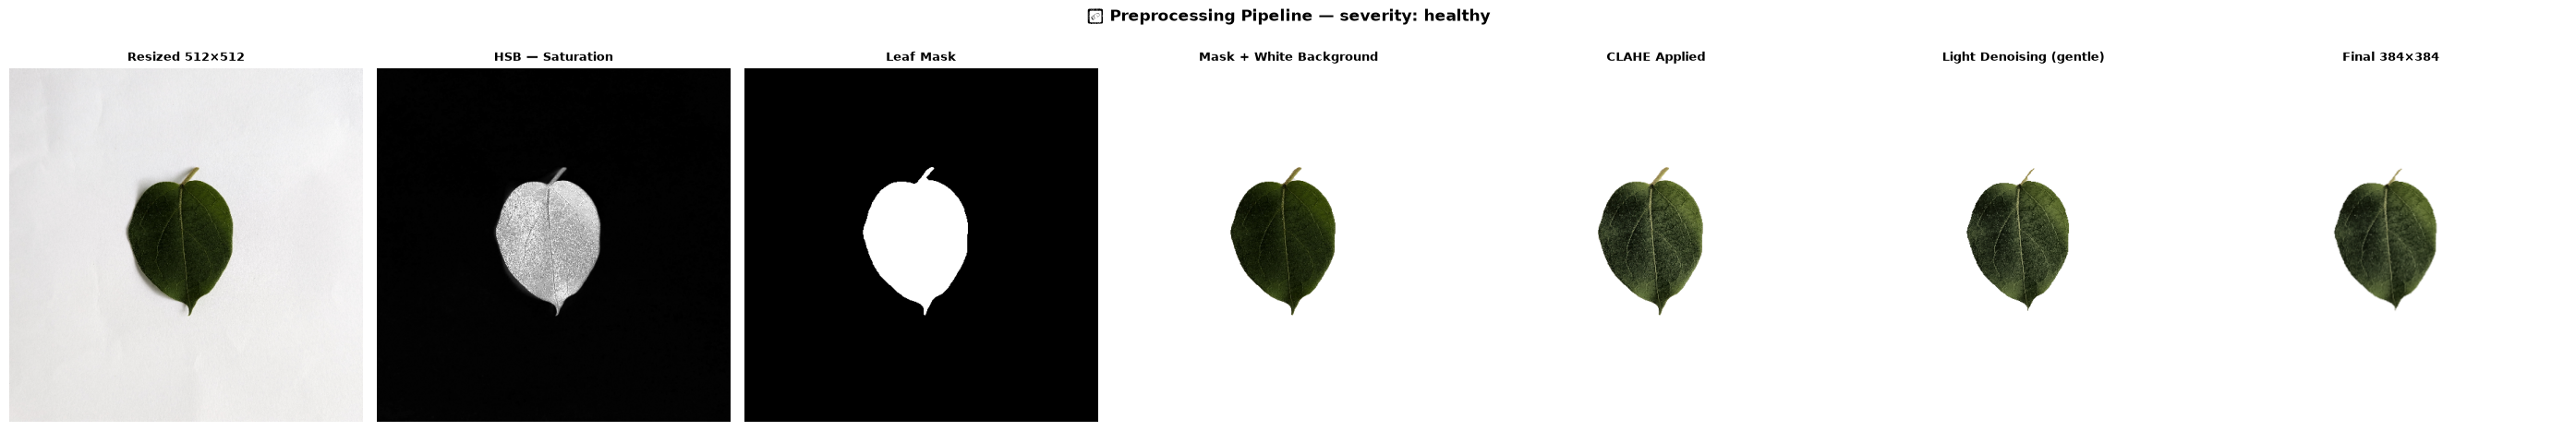

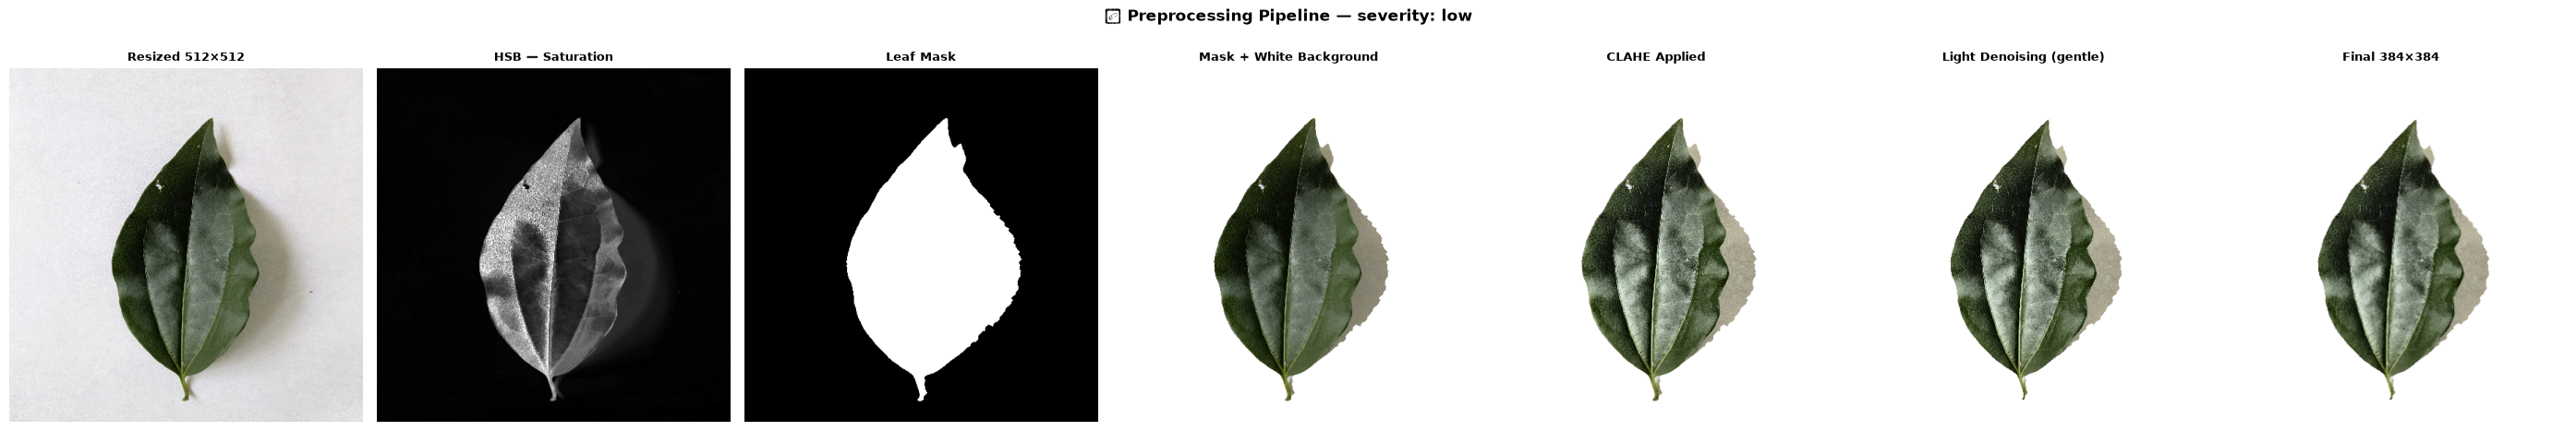

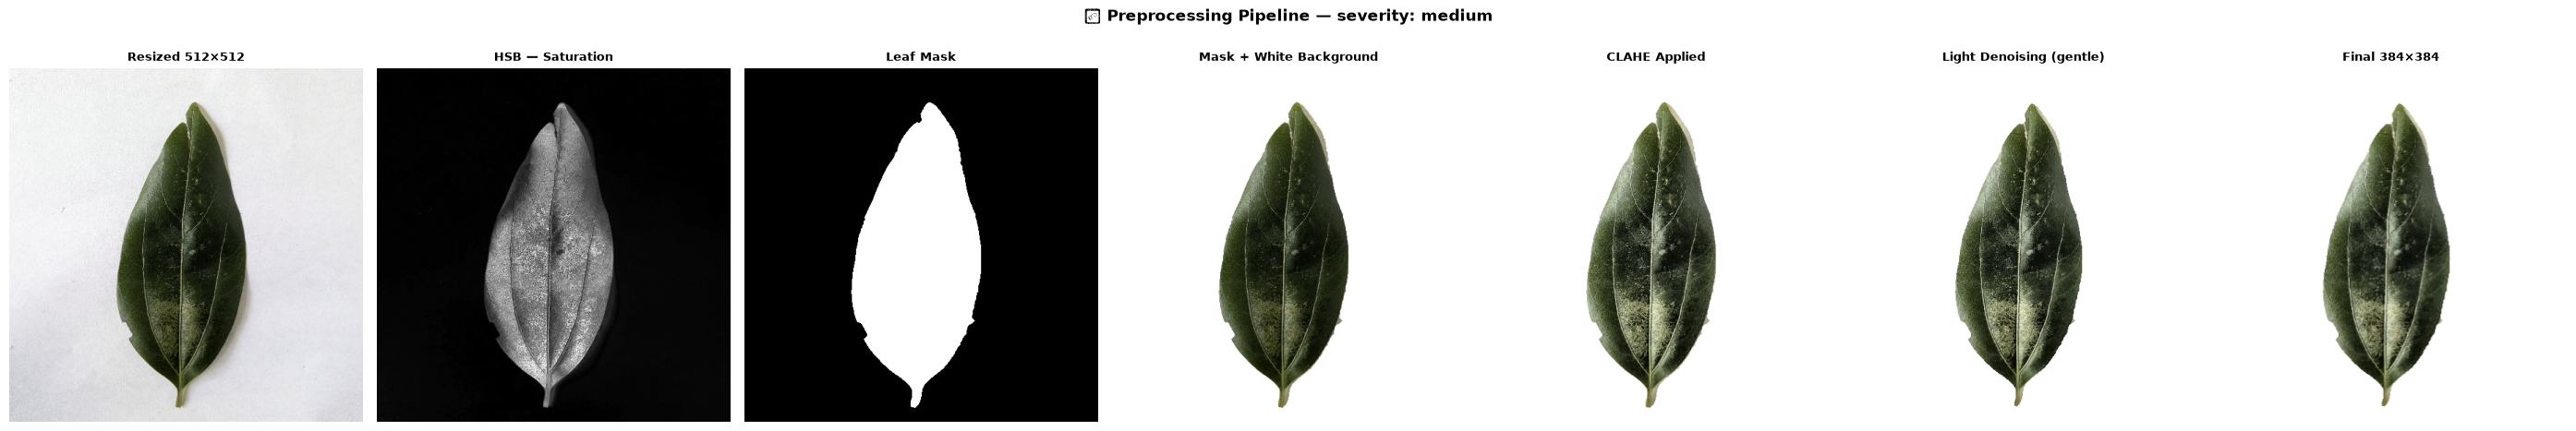

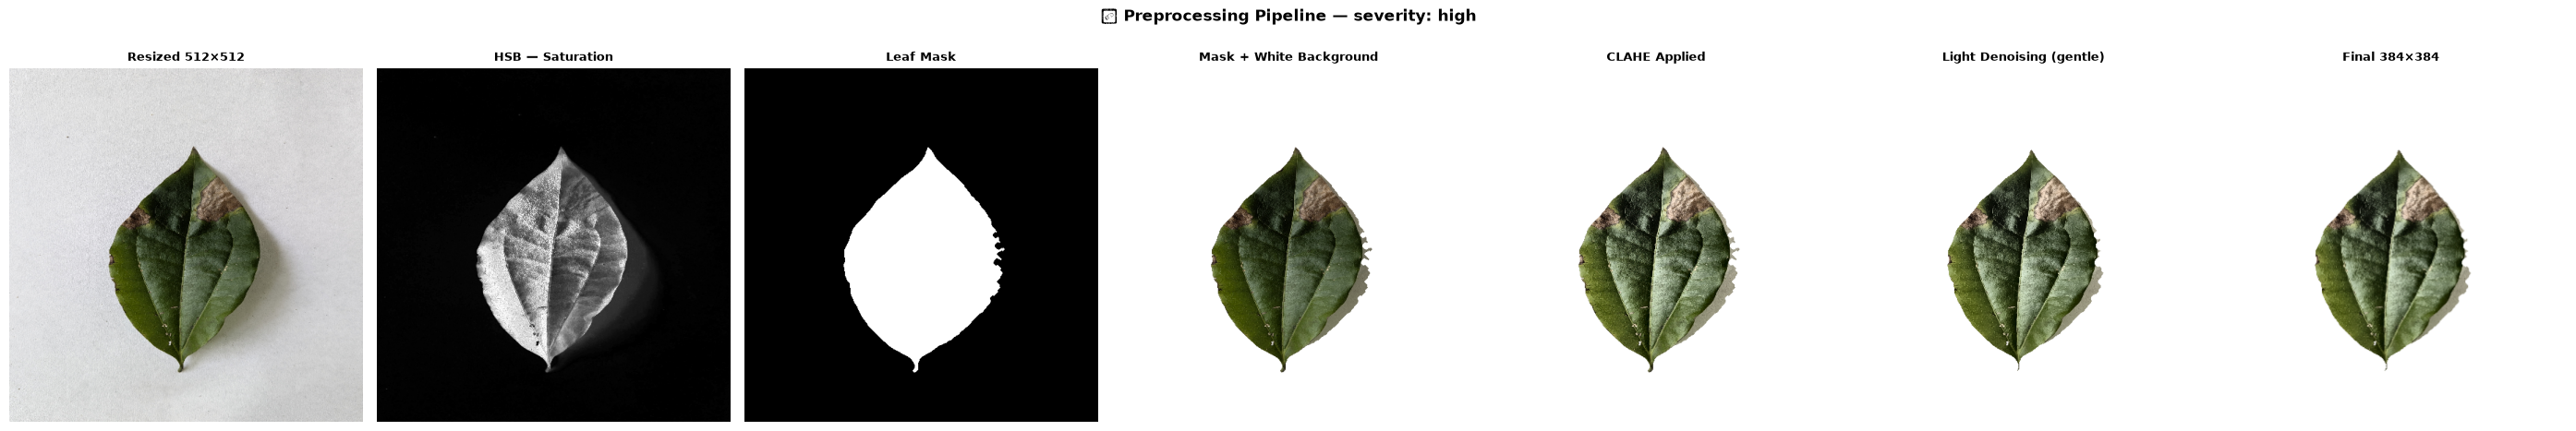

👉 Lesions/dark patches disappearing on "high"? Raise min_shadow_area in segment_leaf() (Cell 5)
👉 Real background/shadow surviving?             Lower min_shadow_area instead
👉 Pale/yellowed leaf area mistaken for background? Lower otsu_relax_factor


In [10]:
def run_and_collect_steps(image_bgr):
    img = cv2.resize(image_bgr, WORK_SIZE)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    saturation_channel = hsv[:, :, 1]

    mask      = segment_leaf(img)
    no_bg     = remove_background(img, mask)
    clahe_img = apply_clahe(no_bg)
    denoised  = apply_light_denoise(clahe_img, mask)
    final     = cv2.resize(denoised, TARGET_SIZE)

    return [
        (bgr2rgb(img),       'Resized 512×512'),
        (saturation_channel, 'HSB — Saturation'),
        (mask,               'Leaf Mask'),
        (bgr2rgb(no_bg),     'Mask + White Background'),
        (bgr2rgb(clahe_img), 'CLAHE Applied'),
        (bgr2rgb(denoised),  'Light Denoising (gentle)'),
        (bgr2rgb(final),     f'Final {TARGET_SIZE[0]}×{TARGET_SIZE[1]}'),
    ]


for severity in SEVERITY_LEVELS:
    sample_imgs = get_images(RAW_HEALTH_PATH, severity, VIEWS[0])
    if not sample_imgs:
        print(f'⚠️  No images found for {severity}/{VIEWS[0]}')
        continue

    sample_bgr = cv2.imread(random.choice(sample_imgs))
    steps = run_and_collect_steps(sample_bgr)

    fig, axes = plt.subplots(1, len(steps), figsize=(28, 5))
    fig.suptitle(f'🩺 Preprocessing Pipeline — severity: {severity}', fontsize=12, fontweight='bold')
    for ax, (img_step, title) in zip(axes, steps):
        ax.imshow(img_step, cmap='gray' if len(img_step.shape) == 2 else None)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{LOGS_PATH}/02Hb_preprocessing_{severity}.png', bbox_inches='tight', dpi=120)
    plt.show()

print('👉 Lesions/dark patches disappearing on "high"? Raise min_shadow_area in segment_leaf() (Cell 5)')
print('👉 Real background/shadow surviving?             Lower min_shadow_area instead')
print('👉 Pale/yellowed leaf area mistaken for background? Lower otsu_relax_factor')

## Cell 8 — Quality Control
Samples 5 images per severity/view, broken down by severity specifically

In [11]:
print('🔍 QUALITY CONTROL — Sampling 5 images per severity/view')
print('=' * 62)

qc_results = []
for severity in SEVERITY_LEVELS:
    for view in VIEWS:
        imgs = get_images(RAW_HEALTH_PATH, severity, view)[:5]
        if not imgs:
            print(f'  ⚠️  No images: {severity}/{view}')
            continue
        for img_path in imgs:
            img = cv2.imread(img_path)
            if img is None:
                continue
            result = preprocess_image(img)
            if result is not None:
                gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
                coverage = (gray < 250).sum() / gray.size * 100
                status = 'PASS' if 2 < coverage < 95 else 'FAIL'
            else:
                coverage, status = 0.0, 'FAIL'
            qc_results.append({'severity': severity, 'view': view,
                                'file': os.path.basename(img_path),
                                'coverage': round(coverage, 1), 'status': status})

qc_df = pd.DataFrame(qc_results)
pass_rate = (qc_df.status == 'PASS').mean() * 100

print(f'\n  Overall pass rate : {pass_rate:.1f}%')
print('\n  Pass rate BY SEVERITY (watch "high" specifically -- most likely to')
print('  reveal segmentation issues from large lesion areas):')
print(qc_df.groupby('severity').apply(
    lambda d: (d.status == 'PASS').mean() * 100).round(1).to_string())
print('\n  Per-severity/view leaf coverage (avg %):')
print(qc_df.groupby(['severity', 'view'])[['coverage']].mean().round(1).to_string())

if pass_rate >= 90:
    print('\n  ✅ QC PASSED — safe to run Cell 9!')
else:
    print('\n  ⚠️  QC issues found:')
    print(qc_df[qc_df.status == 'FAIL'][['severity', 'view', 'file', 'coverage']])

🔍 QUALITY CONTROL — Sampling 5 images per severity/view

  Overall pass rate : 100.0%

  Pass rate BY SEVERITY (watch "high" specifically -- most likely to
  reveal segmentation issues from large lesion areas):
severity
healthy    100.0
high       100.0
low        100.0
medium     100.0

  Per-severity/view leaf coverage (avg %):
                 coverage
severity view            
healthy  bottom      42.1
         top         43.2
high     bottom      41.5
         top         40.7
low      bottom      42.8
         top         43.0
medium   bottom      42.1
         top         43.6

  ✅ QC PASSED — safe to run Cell 9!


## Cell 9 — Run Preprocessing on Full Dataset
⚠️ Only run after Cell 8 QC passes (≥90%)

In [12]:
print('🔄 Starting preprocessing on full health dataset...')
print('=' * 65)

total_saved, total_failed, total_skip = 0, 0, 0

for species in SPECIES_FOLDERS:
    for severity in SEVERITY_LEVELS:
        parts = STATUS_PATH_PARTS[severity]
        for view in VIEWS:
            # 1. Input path (nested: species/healthy/view OR species/damaged/level/view)
            raw_dir = os.path.join(RAW_HEALTH_PATH, species, *parts, view)
            if not os.path.exists(raw_dir):
                continue

            # 2. Collect images
            raw_imgs = (
                glob(os.path.join(raw_dir, '*.jpg')) +
                glob(os.path.join(raw_dir, '*.jpeg')) +
                glob(os.path.join(raw_dir, '*.png'))
            )

            if not raw_imgs:
                continue

            # 3. Create output directory maintaining species + nested structure
            output_dir = os.path.join(PREPROCESSED_PATH, species, *parts, view)
            os.makedirs(output_dir, exist_ok=True)

            ok = 0
            for img_path in tqdm(raw_imgs, desc=f'  {species}/{"/".join(parts)}/{view}'):
                img = cv2.imread(img_path)
                if img is None:
                    total_skip += 1
                    continue

                result = preprocess_image(img)
                if result is not None:
                    fname = os.path.splitext(os.path.basename(img_path))[0]
                    cv2.imwrite(os.path.join(output_dir, f'{fname}_pre.jpg'), result)
                    ok += 1
                    total_saved += 1
                else:
                    total_failed += 1

                del img, result
            gc.collect()

print('=' * 65)
print(f'✅ Done! Saved: {total_saved} | Failed: {total_failed} | Skipped: {total_skip}')
print(f'📁 Output Path: {PREPROCESSED_PATH}')


🔄 Starting preprocessing on full health dataset...


  Wali_Kaha/damaged/high/bottom: 100%|██████████| 15/15 [00:01<00:00,  8.01it/s]

✅ Done! Saved: 840 | Failed: 0 | Skipped: 0
📁 Output Path: C:/Users/User/Documents/UOM/L4S2/Research/Health_New/health_preprocessed


## Cell 10 — Preview Preprocessed Results

C:\Users\User\AppData\Local\Temp\ipykernel_23140\3778372655.py:17: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\User\Documents\Projects\Veda_Vision\ayurveda-recognition\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


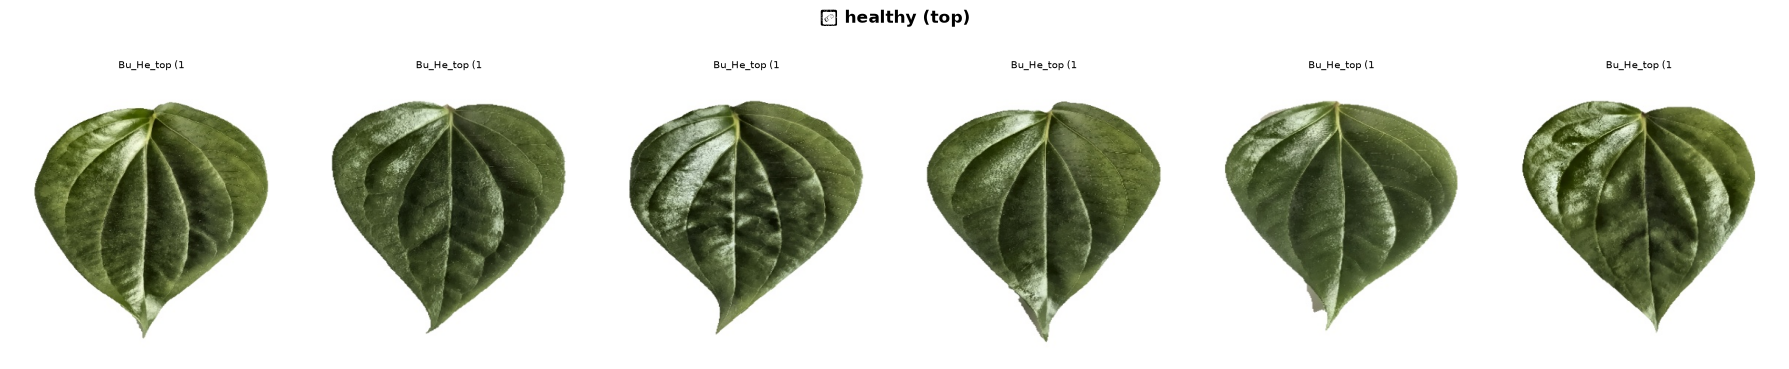

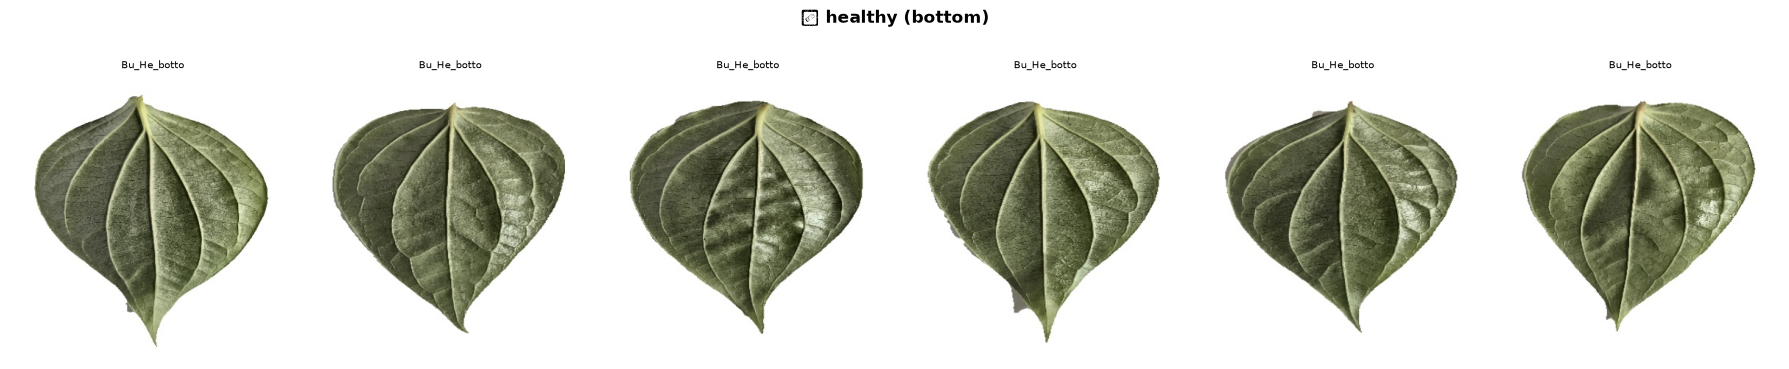

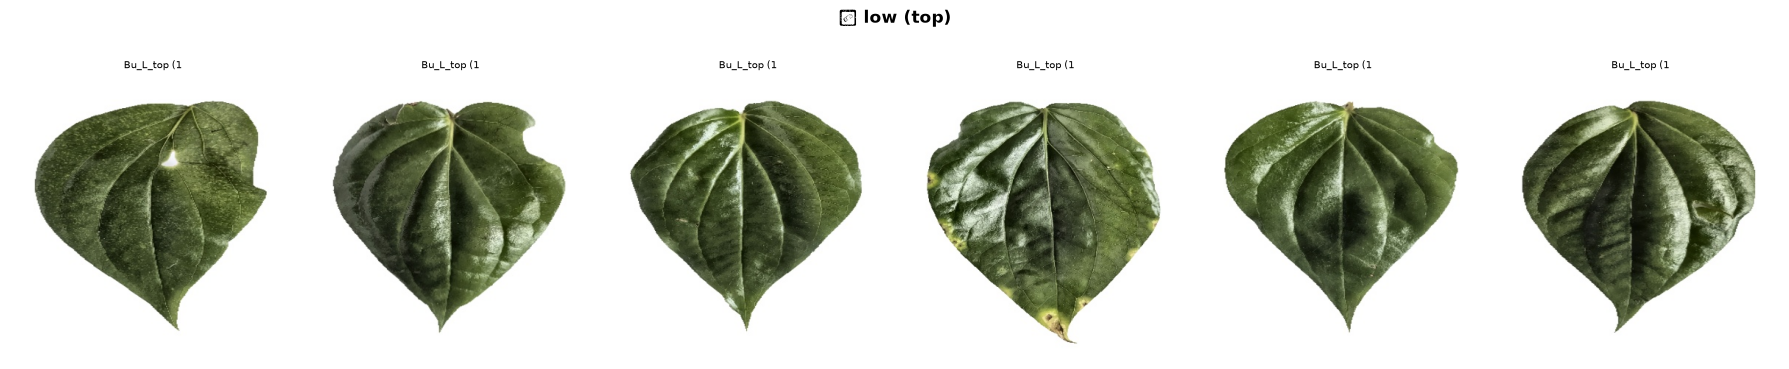

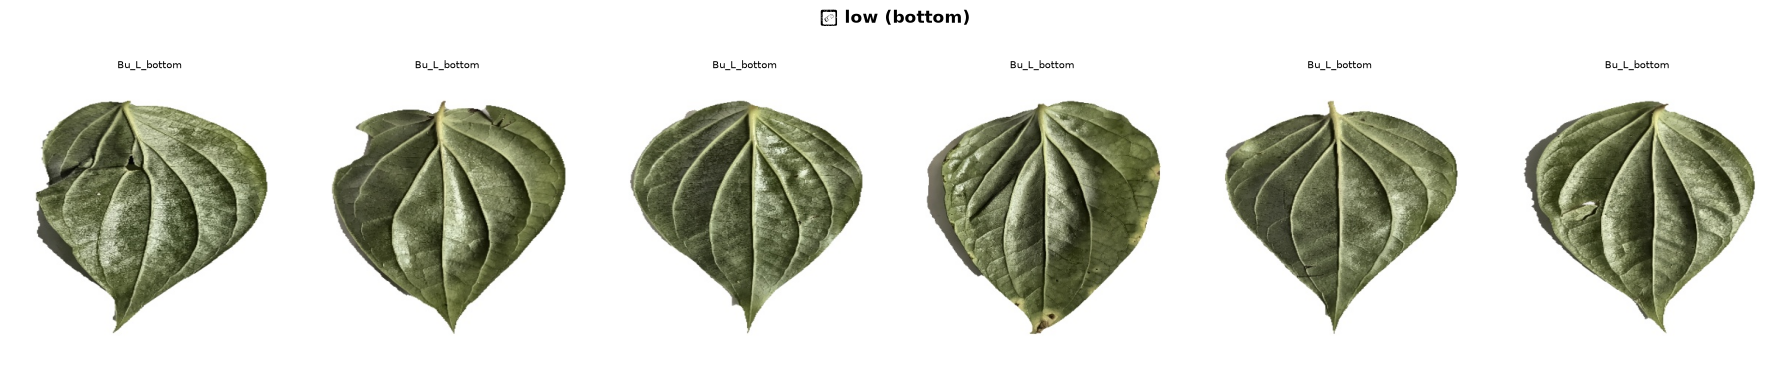

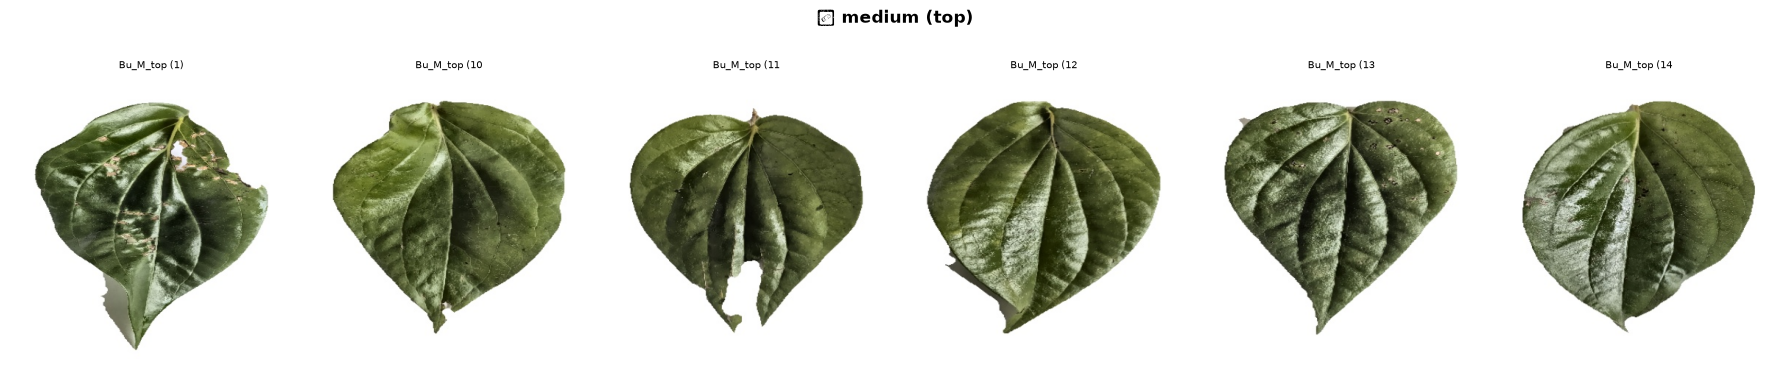

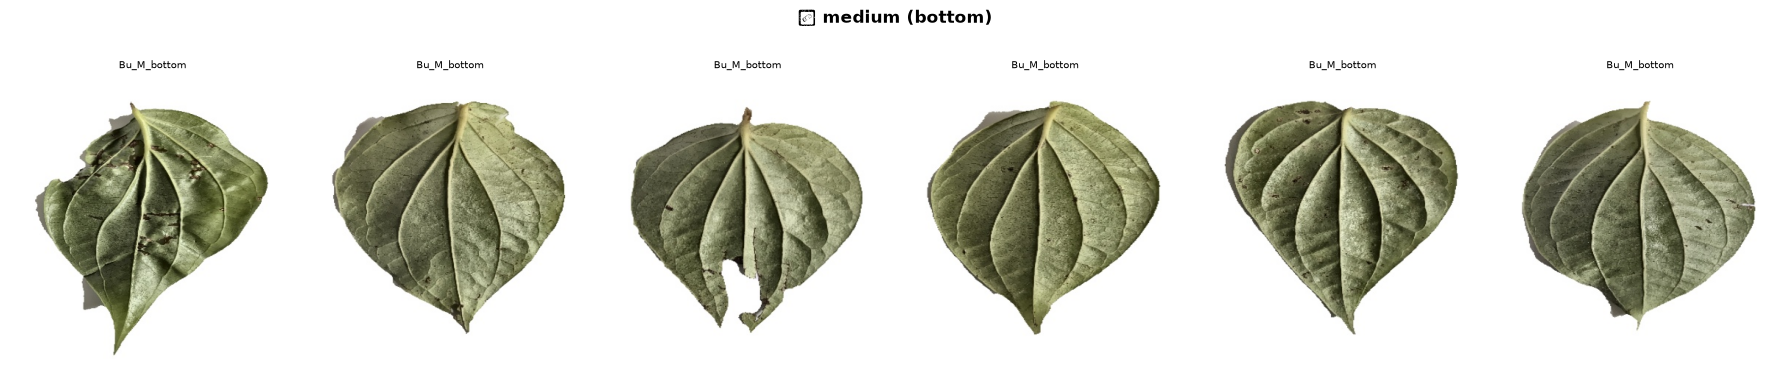

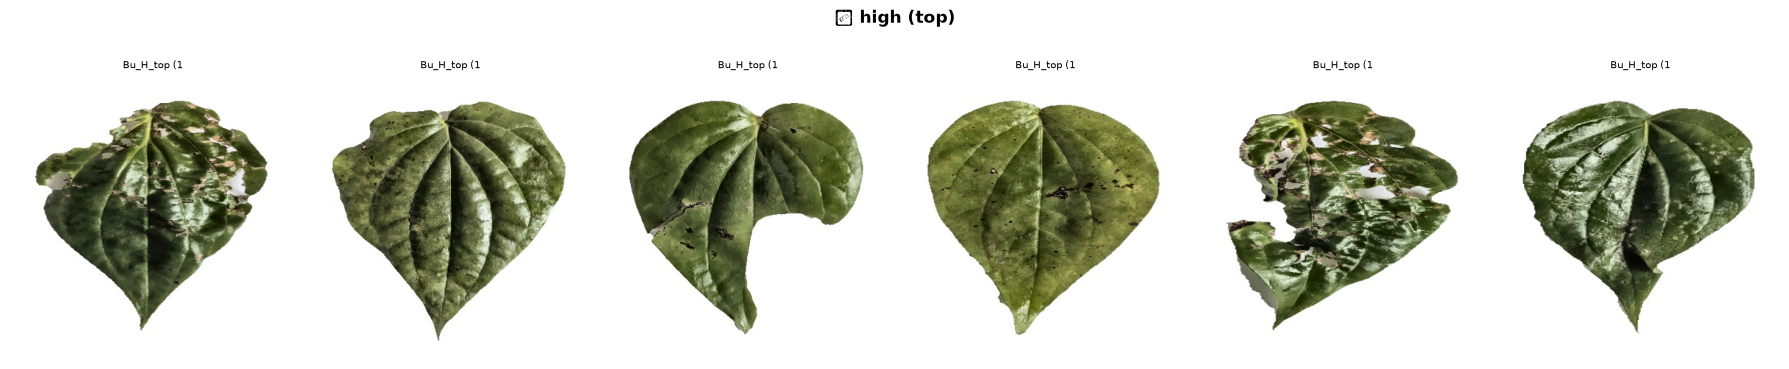

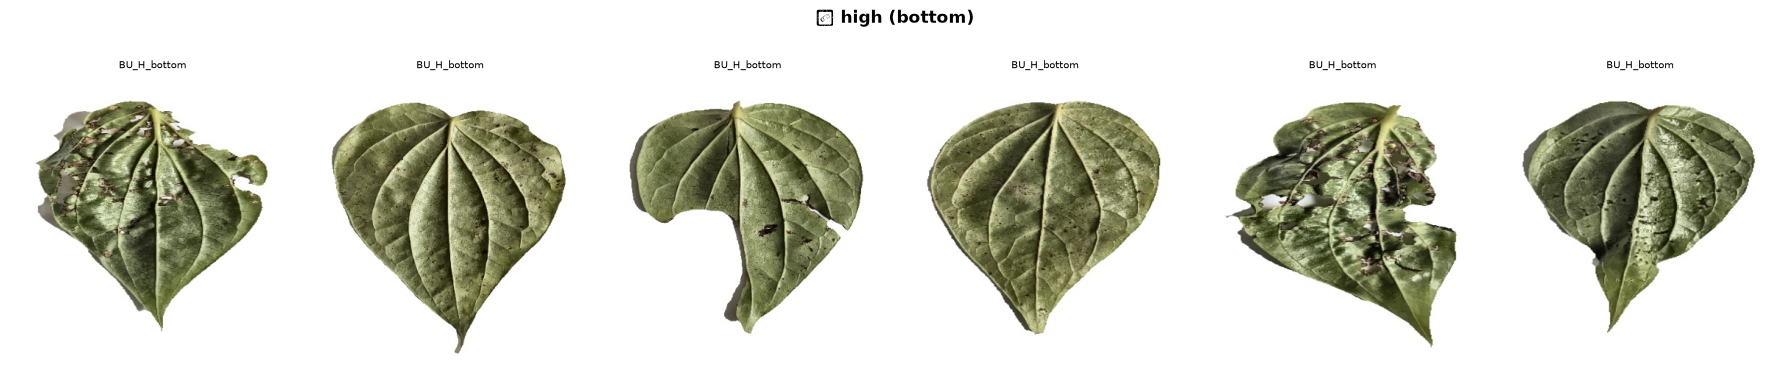

In [13]:
for severity in SEVERITY_LEVELS:
    parts = STATUS_PATH_PARTS[severity]
    for view in VIEWS:
        # wildcard species folder, then nested severity parts, then view
        pattern = os.path.join(PREPROCESSED_PATH, '*', *parts, view, '*.jpg')
        imgs = sorted(glob(pattern))[:6]
        if not imgs:
            continue
        fig, axes = plt.subplots(1, len(imgs), figsize=(len(imgs) * 3, 4))
        fig.suptitle(f'🩺 {severity} ({view})', fontsize=12, fontweight='bold')
        if len(imgs) == 1:
            axes = [axes]
        for ax, fpath in zip(axes, imgs):
            ax.imshow(bgr2rgb(cv2.imread(fpath)))
            ax.set_title(os.path.basename(fpath)[:12], fontsize=7)
            ax.axis('off')
        plt.tight_layout()
        plt.show()


## Cell 11 — Summary

In [14]:
print('📊 DATASET SUMMARY')
print('=' * 55)
for severity in SEVERITY_LEVELS:
    parts = STATUS_PATH_PARTS[severity]
    for view in VIEWS:
        raw = len(get_images(RAW_HEALTH_PATH, severity, view))
        pre_pattern = os.path.join(PREPROCESSED_PATH, '*', *parts, view, '*.jpg')
        pre = len(glob(pre_pattern))
        label = f'{severity}({"/".join(parts)})/{view}'
        print(f'  {label:<28} {raw:>4} -> {pre:>4}')
print('=' * 55)
print()
print('📋 Reminder before splitting into train/test:')
print('   Split by SPECIMEN, not by individual image -- a leaf\'s top')
print('   and bottom photo must stay on the same side of the split.')
print()
print('📋 Next step: build 04H_Feature_Extraction_Health.ipynb')


📊 DATASET SUMMARY
  healthy(healthy)/top          105 ->  105
  healthy(healthy)/bottom       105 ->  105
  low(damaged/low)/top          105 ->  105
  low(damaged/low)/bottom       105 ->  105
  medium(damaged/medium)/top    105 ->  105
  medium(damaged/medium)/bottom  105 ->  105
  high(damaged/high)/top        105 ->  105
  high(damaged/high)/bottom     105 ->  105

📋 Reminder before splitting into train/test:
   Split by SPECIMEN, not by individual image -- a leaf's top
   and bottom photo must stay on the same side of the split.

📋 Next step: build 04H_Feature_Extraction_Health.ipynb
